# Ejercicios CNN

## Objetivos

- Construir CNN desde cero.
- Entender convolución, pooling y extracción automática de características.
- Visualizar filtros y activaciones internas.
- Provocar y corregir overfitting.
- Usar data augmentation.
- Aplicar transfer learning.
- Practicar clasificación, detección y segmentación.
- Construir un mini-pipeline completo de Computer Vision.

> Algunas celdas avanzadas requieren GPU o instalación adicional. Están marcadas como opcionales.

# 0. Instalación y configuración

In [ ]:
# Descomenta en Colab o en un entorno limpio.
# !pip install -q tensorflow matplotlib scikit-learn scikit-image opencv-python pillow pandas
# !pip install -q ultralytics

In [ ]:
import os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponible: []


In [ ]:
def show_images(images, titles=None, cmap=None, cols=5, figsize=(12, 6)):
    n = len(images)
    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap=cmap)
        if titles is not None:
            plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history
    plt.figure(figsize=(8, 4))
    plt.plot(hist.get("accuracy", []), label="accuracy train")
    plt.plot(hist.get("val_accuracy", []), label="accuracy val")
    plt.title(title + " — Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist.get("loss", []), label="loss train")
    plt.plot(hist.get("val_loss", []), label="loss val")
    plt.title(title + " — Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Deep Learning en Computer Vision I

Cómo una CNN aprende filtros y características de manera automática.

# Ejercicio 1 — De filtro clásico a filtro aprendido

## Objetivo
Comparar filtros clásicos con los kernels aprendidos por una CNN.

## Enunciado
Entrena una CNN sencilla sobre MNIST. Después visualiza los filtros de la primera capa convolucional y compáralos con Sobel, Laplace y blur.

## Preguntas
1. ¿Los filtros aprendidos parecen detectar bordes o texturas?
2. ¿Qué diferencia hay entre programar un filtro a mano y aprenderlo?
3. ¿Por qué una CNN puede generalizar mejor que un pipeline clásico rígido?

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


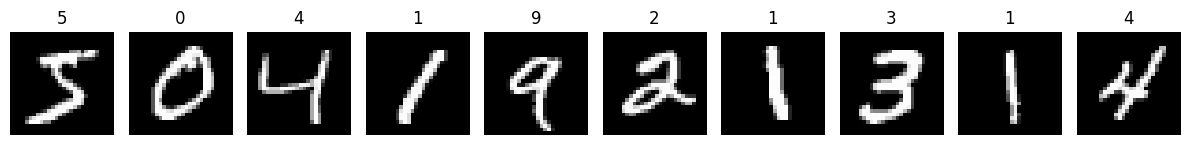

In [ ]:
from tensorflow.keras.datasets import mnist

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0
x_train_mnist = x_train_mnist[..., np.newaxis]
x_test_mnist = x_test_mnist[..., np.newaxis]

show_images(x_train_mnist[:10].squeeze(), [str(y) for y in y_train_mnist[:10]], cmap="gray", cols=10, figsize=(12, 2))

In [ ]:
def build_small_mnist_cnn(filters_1=8, kernel_size=(3, 3)):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters_1, kernel_size, activation="relu", name="conv_1"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (3, 3), activation="relu", name="conv_2"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

mnist_cnn = build_small_mnist_cnn()
mnist_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mnist = mnist_cnn.fit(
    x_train_mnist, y_train_mnist,
    validation_split=0.15,
    epochs=3,
    batch_size=128,
    verbose=1
)
plot_history(history_mnist, "CNN sencilla sobre MNIST")
print("Test:", mnist_cnn.evaluate(x_test_mnist, y_test_mnist, verbose=0))

Epoch 1/3
 94/399 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.4229 - loss: 1.8010

KeyboardInterrupt: 

In [ ]:
weights, biases = mnist_cnn.get_layer("conv_1").get_weights()
kernels = [weights[:, :, 0, i] for i in range(weights.shape[-1])]
show_images(kernels, [f"Filtro {i}" for i in range(len(kernels))], cmap="gray", cols=8, figsize=(12, 2))

In [ ]:
img = x_test_mnist[0].squeeze()
img_u8 = (img * 255).astype(np.uint8)

sobel_x = cv2.Sobel(img_u8, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_u8, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
laplace = cv2.Laplacian(img_u8, cv2.CV_64F)
blur = cv2.GaussianBlur(img_u8, (5, 5), 0)

show_images(
    [img_u8, sobel_x, sobel_y, sobel_mag, laplace, blur],
    ["Original", "Sobel X", "Sobel Y", "Sobel magnitud", "Laplace", "Blur"],
    cmap="gray", cols=6, figsize=(14, 3)
)

## Reto del alumno
Modifica `filters_1` y `kernel_size`. Compara accuracy, número de parámetros y filtros aprendidos.

# Ejercicio 2 — CNN modo LEGO

## Objetivo
Comparar tres modelos:

1. Red densa básica.
2. CNN básica.
3. CNN mejorada con regularización.

## Dataset
Fashion MNIST.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()
class_names_fashion = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

x_train_fashion = x_train_fashion.astype("float32") / 255.0
x_test_fashion = x_test_fashion.astype("float32") / 255.0
x_train_fashion_cnn = x_train_fashion[..., np.newaxis]
x_test_fashion_cnn = x_test_fashion[..., np.newaxis]

show_images(x_train_fashion[:10], [class_names_fashion[y] for y in y_train_fashion[:10]], cmap="gray", cols=10, figsize=(14, 2))

In [ ]:
def build_dense_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def build_basic_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def build_improved_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [ ]:
models_to_train = {
    "Dense básico": (build_dense_model(), x_train_fashion, x_test_fashion),
    "CNN básica": (build_basic_cnn(), x_train_fashion_cnn, x_test_fashion_cnn),
    "CNN mejorada": (build_improved_cnn(), x_train_fashion_cnn, x_test_fashion_cnn),
}

results = []
histories = {}
for name, (model, xtr, xte) in models_to_train.items():
    print("
Entrenando:", name)
    start = time.time()
    hist = model.fit(xtr, y_train_fashion, validation_split=0.15, epochs=3, batch_size=128, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(xte, y_test_fashion, verbose=0)
    results.append({"Modelo": name, "Accuracy test": test_acc, "Loss test": test_loss, "Nº parámetros": model.count_params(), "Tiempo (s)": elapsed})
    histories[name] = hist

pd.DataFrame(results)

## Reto del alumno
Explica qué modelo generaliza mejor y si el modelo con más parámetros es necesariamente el mejor.

# Ejercicio 3 — Visualizando lo que ve la red

## Objetivo
Visualizar activaciones internas de una CNN.

In [ ]:
cnn_for_activations = models_to_train["CNN básica"][0]
conv_layers = [layer.name for layer in cnn_for_activations.layers if isinstance(layer, layers.Conv2D)]
print("Capas convolucionales:", conv_layers)

sample_idx = 0
sample_img = x_test_fashion_cnn[sample_idx:sample_idx+1]

activation_model = keras.Model(
    inputs=cnn_for_activations.inputs,
    outputs=[cnn_for_activations.get_layer(name).output for name in conv_layers]
)
activations = activation_model.predict(sample_img)

plt.imshow(sample_img.squeeze(), cmap="gray")
plt.title(f"Imagen original: {class_names_fashion[y_test_fashion[sample_idx]]}")
plt.axis("off")
plt.show()

In [ ]:
def show_activation_maps(activation, max_maps=16):
    activation = activation[0]
    n_maps = min(max_maps, activation.shape[-1])
    maps = [activation[:, :, i] for i in range(n_maps)]
    show_images(maps, [f"Mapa {i}" for i in range(n_maps)], cmap="viridis", cols=8, figsize=(14, 4))

for layer_name, activation in zip(conv_layers, activations):
    print("Capa:", layer_name, "Shape:", activation.shape)
    show_activation_maps(activation)

## Reto del alumno
Compara activaciones para una imagen bien clasificada y otra mal clasificada.

# Ejercicio 4 — Overfitting a propósito

## Objetivo
Provocar sobreajuste y corregirlo con regularización.

In [ ]:
small_train_size = 800
x_small = x_train_fashion_cnn[:small_train_size]
y_small = y_train_fashion[:small_train_size]
print(x_small.shape, y_small.shape)

In [ ]:
def build_overfit_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

overfit_model = build_overfit_cnn()
hist_overfit = overfit_model.fit(x_small, y_small, validation_split=0.3, epochs=8, batch_size=64, verbose=1)
plot_history(hist_overfit, "Overfitting provocado")

In [ ]:
def build_regularized_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

regularized_model = build_regularized_cnn()
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
hist_reg = regularized_model.fit(x_small, y_small, validation_split=0.3, epochs=15, batch_size=64, callbacks=callbacks, verbose=1)
plot_history(hist_reg, "Modelo regularizado")

## Reto del alumno
Prueba dropout bajo, medio y alto. Explica cuándo ayuda y cuándo perjudica.

# Ejercicio 5 — Data augmentation

## Objetivo
Visualizar transformaciones y decidir cuáles son coherentes para el problema.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

img = x_train_fashion_cnn[12:13]
augmented_images = [data_augmentation(img, training=True).numpy()[0].squeeze() for _ in range(12)]
show_images([img[0].squeeze()] + augmented_images, ["Original"] + [f"Aug {i}" for i in range(12)], cmap="gray", cols=7, figsize=(14, 5))

## Preguntas
1. ¿Tiene sentido hacer flip horizontal en todas las clases?
2. ¿Qué pasaría con rotaciones demasiado grandes?
3. ¿Qué transformaciones serían peligrosas en MNIST?

# Ejercicio 6 — Transfer learning express

## Objetivo
Comparar CNN desde cero con MobileNetV2 preentrenada.

Usaremos CIFAR-10 reducido a dos clases: avión vs automóvil.

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
y_train_cifar = y_train_cifar.squeeze()
y_test_cifar = y_test_cifar.squeeze()

selected_classes = [0, 1]
class_names_cifar_binary = ["airplane", "automobile"]
train_mask = np.isin(y_train_cifar, selected_classes)
test_mask = np.isin(y_test_cifar, selected_classes)

x_train_bin = x_train_cifar[train_mask].astype("float32") / 255.0
y_train_bin = y_train_cifar[train_mask].astype("float32")
x_test_bin = x_test_cifar[test_mask].astype("float32") / 255.0
y_test_bin = y_test_cifar[test_mask].astype("float32")

show_images(x_train_bin[:10], [class_names_cifar_binary[int(y)] for y in y_train_bin[:10]], cols=10, figsize=(14, 2))

In [ ]:
def build_cifar_cnn_from_scratch():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

scratch_model = build_cifar_cnn_from_scratch()
hist_scratch = scratch_model.fit(x_train_bin, y_train_bin, validation_split=0.2, epochs=5, batch_size=64, verbose=1)
plot_history(hist_scratch, "CNN desde cero")
print("Test:", scratch_model.evaluate(x_test_bin, y_test_bin, verbose=0))

In [ ]:
IMG_SIZE = 96
base_model = keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

transfer_model = keras.Model(inputs, outputs)
transfer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_transfer = transfer_model.fit(x_train_bin, y_train_bin, validation_split=0.2, epochs=3, batch_size=64, verbose=1)
plot_history(hist_transfer, "Transfer learning")
print("Test:", transfer_model.evaluate(x_test_bin, y_test_bin, verbose=0))

## Reto del alumno
Descongela las últimas 20 capas de MobileNetV2 y realiza fine tuning con `learning_rate=1e-5`.